# Hyperparameter Tuning Code-Along

In machine learning, a model has two kinds of parameters:

- **Learned parameters** — values the model figures out on its own during training (e.g. coefficients in a regression)
- **Hyperparameters** — values *you* set before training that control how the model learns (e.g. `alpha` in Lasso/Ridge)

Choosing the right hyperparameters can make the difference between a mediocre and a great model. In this notebook we'll work through a principled workflow for finding them:

1. **Establish a baseline** — train a model with default settings so we have something to beat
2. **Diagnose with a validation curve** — visualize how MSE changes across a range of hyperparameter values
3. **Search for the best value** — use `GridSearchCV` and `RandomizedSearchCV` to find the optimal hyperparameter precisely
4. **Evaluate on the test set** — report final performance on held-out data

---

## The Dataset

We'll be using the **diabetes dataset** from sklearn throughout this notebook. Here's what you need to know about it:

- **442 patients**, each described by **10 features** measured at a baseline visit: age, sex, BMI, average blood pressure, and six blood serum measurements
- The **target variable** is a quantitative measure of **disease progression one year after baseline** — a continuous value roughly ranging from 25 to 346
- All features have already been **mean-centered and scaled** by the standard deviation, so each one has a mean of approximately zero
- Because the target is a real-valued continuous number, this is a **regression problem**

Since the target is in its own arbitrary units (a disease progression score), **MSE and RMSE are our metrics of choice**. Unlike R², MSE is what regularized models actually minimize during training, so optimizing for it during hyperparameter search is consistent with how the model was built. RMSE (the square root of MSE) puts the error back in the same units as the target, which makes it easier to interpret — an RMSE of 50 means our predictions are off by about 50 progression points on average.

## Imports

Run this cell first to load everything we need.

In [2]:
# toy diabetes dataset
from sklearn.datasets import load_diabetes

# regressor models
from sklearn.linear_model import Lasso, Ridge, ElasticNet

# accuracy metrics
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# train/test/CV split and tuning tools
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# used to measure how long each search takes
import time

---
## Step 1 — Load the Data

We'll split the dataset once and reuse the same train/test sets across all three models so our comparisons are fair — each model sees exactly the same held-out test data.

In [3]:
# load_diabetes returns a Bunch object; as_frame=True gives us pandas DataFrames
X, y = load_diabetes(return_X_y=True, as_frame=True)

# reserve 20% of the data for final evaluation
# random_state=42 ensures everyone gets the same split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test:  {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test:  {y_test.shape}")
print()
print(f"Target range: {y.min():.1f} to {y.max():.1f}")
print(f"Target mean:  {y.mean():.1f}")

Shape of X_train: (353, 10)
Shape of X_test:  (89, 10)
Shape of y_train: (353,)
Shape of y_test:  (89,)

Target range: 25.0 to 346.0
Target mean:  152.1


---
## Part 1 — Lasso Regression (Worked Example)

Lasso adds an **L1 penalty** to the loss function that shrinks coefficients toward zero — and can eliminate features entirely by setting their coefficients to exactly zero. The strength of this penalty is controlled by `alpha`:

- **Small alpha** → weak regularization, model is more flexible and fits training data closely
- **Large alpha** → strong regularization, model is simpler and may underfit

We'll walk through the full workflow here so you can use it as a reference for Ridge and ElasticNet.

### 1a — Baseline

Always start with a baseline. Training a model at default settings gives us a reference point — if our tuned model can't beat this, something has gone wrong.

In [4]:
# train Lasso with sklearn's default alpha=1.0
lasso_baseline = Lasso(alpha=1.0)
lasso_baseline.fit(X_train, y_train)

# generate predictions on the held-out test set
y_pred_lasso_baseline = lasso_baseline.predict(X_test)

# MSE: average squared difference between predictions and true values
# RMSE: square root of MSE — puts error back in the same units as the target
mse_lasso_baseline  = mean_squared_error(y_test, y_pred_lasso_baseline)
rmse_lasso_baseline = root_mean_squared_error(y_test, y_pred_lasso_baseline)

print(f"Lasso Baseline (alpha=1.0)")
print(f"  MSE:  {mse_lasso_baseline:.2f}")
print(f"  RMSE: {rmse_lasso_baseline:.2f}")
print()
print("This is our target to beat. Keep this number in mind as we tune.")

Lasso Baseline (alpha=1.0)
  MSE:  3403.58
  RMSE: 58.34

This is our target to beat. Keep this number in mind as we tune.


### 1b — Validation Curve

Before searching, we look at the landscape. The validation curve sweeps across all alpha values and shows us where MSE is lowest and where the model starts to degrade. Think of it as the **map** — it tells us which region is worth searching before we send in GridSearch as the **GPS** to pinpoint the exact best value.

> **Note on alpha spacing:** We use `np.logspace` here because regularization strength acts multiplicatively — the difference between alpha=0.001 and alpha=0.01 is much more significant than between alpha=5 and alpha=6. Equal spacing on a log scale gives us far better resolution in the low-alpha region where the interesting behavior actually happens. Try swapping in `np.linspace` and see how the curve changes!

> **Note on scoring:** `validation_curve` uses `scoring='neg_mean_squared_error'` — sklearn's convention for minimization problems is to negate the score so that "higher is better" always holds internally. We flip the sign back when plotting so we're looking at regular positive MSE values.

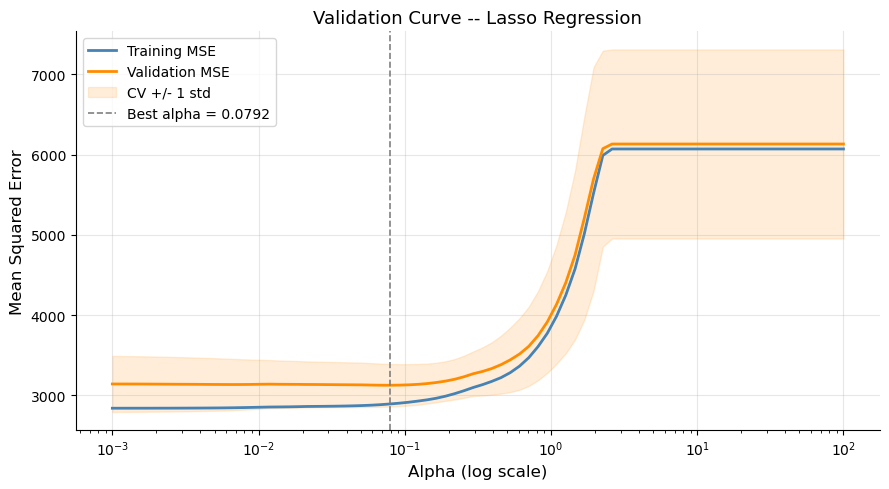

Best alpha from validation curve: 0.0792
Lowest CV MSE at that alpha:      3125.39


In [5]:
# define the range of alpha values to sweep
# logspace(-3, 2, 80) gives us 80 points evenly spaced on a log scale from 0.001 to 100
alphas = np.logspace(-3, 2, 80)

# validation_curve trains and evaluates the model at every alpha value using 5-fold CV
# for each alpha it returns train and validation scores across all 5 folds
# neg_mean_squared_error: sklearn negates MSE so higher = better (its internal convention)
train_scores, val_scores = validation_curve(
    Lasso(),           # the model to evaluate
    X_train, y_train,  # training data only — test set stays hidden
    param_name='alpha',
    param_range=alphas,
    cv=5,
    scoring='neg_mean_squared_error'
)

# average across the 5 folds and flip the sign to get positive MSE values
train_mse_mean = -train_scores.mean(axis=1)
val_mse_mean   = -val_scores.mean(axis=1)
# std tells us how stable the CV estimate is — wider band means less reliable
val_mse_std    = val_scores.std(axis=1)

# find the alpha with the lowest cross-validation MSE
best_alpha_lasso_vc = alphas[val_mse_mean.argmin()]

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(alphas, train_mse_mean, label='Training MSE',   color='steelblue',  linewidth=2)
ax.plot(alphas, val_mse_mean,   label='Validation MSE', color='darkorange', linewidth=2)

# shaded band shows +/- 1 std across folds
# a wide band means CV results were inconsistent — don't trust alpha values in that region
ax.fill_between(
    alphas,
    val_mse_mean - val_mse_std,
    val_mse_mean + val_mse_std,
    alpha=0.15, color='darkorange', label='CV +/- 1 std'
)

# mark the best alpha so we can visually confirm the search range makes sense
ax.axvline(best_alpha_lasso_vc, color='gray', linestyle='--', linewidth=1.2,
           label=f'Best alpha = {best_alpha_lasso_vc:.4f}')

ax.set_xscale('log')  # log scale on x-axis matches our logspace alpha range
ax.set_xlabel('Alpha (log scale)', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Validation Curve -- Lasso Regression', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Best alpha from validation curve: {best_alpha_lasso_vc:.4f}")
print(f"Lowest CV MSE at that alpha:      {val_mse_mean.min():.2f}")

### 1c — GridSearchCV vs RandomizedSearchCV

The validation curve showed us where to look. Now we use GridSearch and RandomSearch to pinpoint the best alpha — and time both so we can see the speed tradeoff directly.

For a single hyperparameter like alpha, the validation curve already gave us most of what we need. GridSearch and RandomSearch really earn their keep when we have **multiple interacting hyperparameters** — which is exactly what we'll see in the ElasticNet section.

In [6]:
# define the grid of alpha values to search
# this is a dictionary: keys are parameter names, values are lists of candidates
alpha_grid = {'alpha': np.linspace(0.01, 10, 100)}

# --- GridSearchCV ---
# evaluates every single value in alpha_grid using 5-fold CV
# neg_mean_squared_error: same sklearn convention as before
start = time.time()
grid_search = GridSearchCV(
    estimator=Lasso(),
    param_grid=alpha_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)
elapsed_grid = time.time() - start

# best_estimator_ is the model retrained on all of X_train with the best alpha
y_pred_lasso_grid  = grid_search.best_estimator_.predict(X_test)
mse_lasso_grid     = mean_squared_error(y_test, y_pred_lasso_grid)
rmse_lasso_grid    = root_mean_squared_error(y_test, y_pred_lasso_grid)

print(f"GridSearchCV")
print(f"  Best alpha: {grid_search.best_params_['alpha']:.4f}")
print(f"  Test MSE:   {mse_lasso_grid:.2f}")
print(f"  Test RMSE:  {rmse_lasso_grid:.2f}")
print(f"  Time:       {elapsed_grid:.2f}s")

GridSearchCV
  Best alpha: 0.1109
  Test MSE:   2798.16
  Test RMSE:  52.90
  Time:       0.38s


In [7]:
# --- RandomizedSearchCV ---
# instead of evaluating every value, randomly samples n_iter=10 (default) candidates
# much faster, usually finds a near-optimal value
start = time.time()
random_search = RandomizedSearchCV(
    estimator=Lasso(),
    param_distributions=alpha_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42  # for reproducibility
)
random_search.fit(X_train, y_train)
elapsed_random = time.time() - start

y_pred_lasso_random  = random_search.best_estimator_.predict(X_test)
mse_lasso_random     = mean_squared_error(y_test, y_pred_lasso_random)
rmse_lasso_random    = root_mean_squared_error(y_test, y_pred_lasso_random)

print(f"RandomizedSearchCV")
print(f"  Best alpha: {random_search.best_params_['alpha']:.4f}")
print(f"  Test MSE:   {mse_lasso_random:.2f}")
print(f"  Test RMSE:  {rmse_lasso_random:.2f}")
print(f"  Time:       {elapsed_random:.2f}s")
print()

# summary table — lower MSE/RMSE is better
print("=" * 52)
print(f"{'Method':<25} {'MSE':>8}  {'RMSE':>8}  {'Time':>6}")
print("-" * 52)
print(f"{'Baseline (alpha=1.0)':<25} {mse_lasso_baseline:>8.2f}  {rmse_lasso_baseline:>8.2f}")
print(f"{'GridSearchCV':<25} {mse_lasso_grid:>8.2f}  {rmse_lasso_grid:>8.2f}  {elapsed_grid:>4.2f}s")
print(f"{'RandomizedSearchCV':<25} {mse_lasso_random:>8.2f}  {rmse_lasso_random:>8.2f}  {elapsed_random:>4.2f}s")
print("=" * 52)

RandomizedSearchCV
  Best alpha: 0.0100
  Test MSE:   2878.56
  Test RMSE:  53.65
  Time:       0.05s

Method                         MSE      RMSE    Time
----------------------------------------------------
Baseline (alpha=1.0)       3403.58     58.34
GridSearchCV               2798.16     52.90  0.38s
RandomizedSearchCV         2878.56     53.65  0.05s


---
## Part 2 — Ridge Regression (Guided Practice)

**Ridge regression** uses an **L2 penalty** — instead of zeroing coefficients out like Lasso, it shrinks them all toward zero smoothly. This makes it a better fit for datasets where all features carry some signal, since no predictor is ever discarded entirely.

Follow the same workflow as Lasso above. The TODOs will guide you through each step.

> **Be sure to stick to the same naming convention**

### 2a — Baseline

In [8]:
# TODO: train a Ridge model with default alpha=1.0
# Print MSE and RMSE on the test set
ridge_baseline = Ridge(alpha=1)
ridge_baseline.fit(X_train, y_train)

y_pred_ridge_baseline = ridge_baseline.predict(X_test)
mse_ridge_baseline    = mean_squared_error(y_test, y_pred_ridge_baseline)
rmse_ridge_baseline   = root_mean_squared_error(y_test, y_pred_ridge_baseline)

print(f"Ridge Baseline (alpha=1.0)")
print(f"  MSE:  {mse_ridge_baseline:.2f}")
print(f"  RMSE: {rmse_ridge_baseline:.2f}")

Ridge Baseline (alpha=1.0)
  MSE:  3077.42
  RMSE: 55.47


### 2b — Validation Curve

Use the Lasso validation curve code above as a template — the only change is the model.

**Reflect as you run this:** How does the Ridge curve compare to Lasso? Is the sweet spot (low MSE region) wider or narrower? Does the MSE climb more or less sharply at high alpha values? Think about why the two penalty types might behave differently.

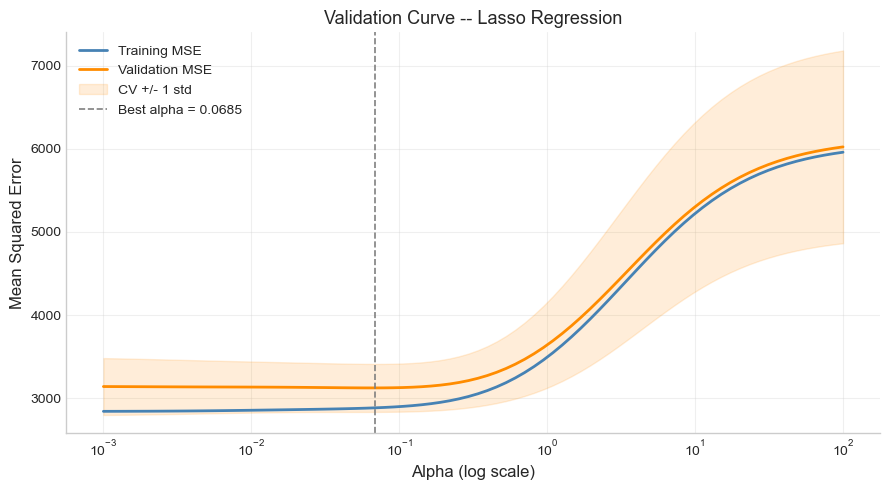

Best alpha from validation curve: 0.0685
Lowest CV MSE at that alpha:      3121.91


In [30]:
# TODO: plot a validation curve for Ridge regression
# Use np.logspace(-3, 2, 80) for the alpha range
# Score by 'neg_mean_squared_error', flip the sign when plotting
# Plot both training and CV MSE vs alpha on a log x-axis
# Add the +/- 1 std shaded band and mark the best alpha with a dashed line

# define the range of alpha values to sweep
# logspace(-3, 2, 80) gives us 80 points evenly spaced on a log scale from 0.001 to 100
alphas1 = np.logspace(-3, 2, 80)

# validation_curve trains and evaluates the model at every alpha value using 5-fold CV
# for each alpha it returns train and validation scores across all 5 folds
# neg_mean_squared_error: sklearn negates MSE so higher = better (its internal convention)
train_scores1, val_scores1 = validation_curve(
    Ridge(),           # the model to evaluate
    X_train, y_train,  # training data only — test set stays hidden
    param_name='alpha',
    param_range=alphas,
    cv=5,
    scoring='neg_mean_squared_error'
)

# average across the 5 folds and flip the sign to get positive MSE values
train_mse_mean1 = -train_scores1.mean(axis=1)
val_mse_mean1   = -val_scores1.mean(axis=1)
# std tells us how stable the CV estimate is — wider band means less reliable
val_mse_std1    = val_scores1.std(axis=1)

# find the alpha with the lowest cross-validation MSE
best_alpha_ridge_vc = alphas1[val_mse_mean1.argmin()]

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(alphas1, train_mse_mean1, label='Training MSE',   color='steelblue',  linewidth=2)
ax.plot(alphas1, val_mse_mean1,   label='Validation MSE', color='darkorange', linewidth=2)

# shaded band shows +/- 1 std across folds
# a wide band means CV results were inconsistent — don't trust alpha values in that region
ax.fill_between(
    alphas1,
    val_mse_mean1 - val_mse_std1,
    val_mse_mean1 + val_mse_std1,
    alpha=0.15, color='darkorange', label='CV +/- 1 std'
)

# mark the best alpha so we can visually confirm the search range makes sense
ax.axvline(best_alpha_ridge_vc, color='gray', linestyle='--', linewidth=1.2,
           label=f'Best alpha = {best_alpha_ridge_vc:.4f}')

ax.set_xscale('log')  # log scale on x-axis matches our logspace alpha range
ax.set_xlabel('Alpha (log scale)', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Validation Curve -- Lasso Regression', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Best alpha from validation curve: {best_alpha_ridge_vc:.4f}")
print(f"Lowest CV MSE at that alpha:      {val_mse_mean.min():.2f}")




### 2c — GridSearchCV and RandomizedSearchCV

This time, add `fit_intercept` as a second hyperparameter. This controls whether the model is allowed to shift the regression line up or down (i.e. learn a y-intercept). Setting it to `False` forces the line through the origin — only appropriate if you know your data is centered around zero.

With two hyperparameters, GridSearch now evaluates every *combination* of alpha and fit_intercept. This is where it starts to become genuinely more useful than just reading a validation curve.

In [21]:
# TODO: tune Ridge using GridSearchCV over both alpha and fit_intercept
# param_grid should include:
#   'alpha': np.linspace(0.01, 10, 100)
#   'fit_intercept': [True, False]
# Score by 'neg_mean_squared_error', use cv=5, and time the search
# Print best params, test MSE, test RMSE, and elapsed time

# define the grid of alpha values to search
# this is a dictionary: keys are parameter names, values are lists of candidates
alpha_grid1 = {'alpha': np.linspace(0.01, 10, 100)}

# --- GridSearchCV ---
# evaluates every single value in alpha_grid using 5-fold CV
# neg_mean_squared_error: same sklearn convention as before
start1 = time.time()
grid_search1 = GridSearchCV(
    estimator=Lasso(),
    param_grid=alpha_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_search1.fit(X_train, y_train)
elapsed_grid1 = time.time() - start

# best_estimator_ is the model retrained on all of X_train with the best alpha
y_pred_ridge_grid  = grid_search1.best_estimator_.predict(X_test)
mse_ridge_grid     = mean_squared_error(y_test, y_pred_ridge_grid)
rmse_ridge_grid    = root_mean_squared_error(y_test, y_pred_ridge_grid)

print(f"GridSearchCV")
print(f"  Best alpha: {grid_search1.best_params_['alpha']:.4f}")
print(f"  Test MSE:   {mse_ridge_grid:.2f}")
print(f"  Test RMSE:  {rmse_ridge_grid:.2f}")
print(f"  Time:       {elapsed_grid1:.2f}s")



GridSearchCV
  Best alpha: 0.1109
  Test MSE:   2798.16
  Test RMSE:  52.90
  Time:       295.57s


In [24]:
# TODO: repeat with RandomizedSearchCV using the same param distributions
# Print best params, test MSE, test RMSE, and elapsed time
# Then print a summary table comparing baseline, GridSearch, and RandomSearch

# --- RandomizedSearchCV ---
# instead of evaluating every value, randomly samples n_iter=10 (default) candidates
# much faster, usually finds a near-optimal value
start1 = time.time()
random_search1 = RandomizedSearchCV(
    estimator=Ridge(),
    param_distributions=alpha_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42  # for reproducibility
)
random_search1.fit(X_train, y_train)
elapsed_random1 = time.time() - start1

y_pred_ridge_random  = random_search.best_estimator_.predict(X_test)
mse_ridge_random     = mean_squared_error(y_test, y_pred_lasso_random)
rmse_ridge_random    = root_mean_squared_error(y_test, y_pred_lasso_random)

print(f"RandomizedSearchCV")
print(f"  Best alpha: {random_search1.best_params_['alpha']:.4f}")
print(f"  Test MSE:   {mse_ridge_random:.2f}")
print(f"  Test RMSE:  {rmse_ridge_random:.2f}")
print(f"  Time:       {elapsed_random1:.2f}s")
print()

# summary table — lower MSE/RMSE is better
print("=" * 52)
print(f"{'Method':<25} {'MSE':>8}  {'RMSE':>8}  {'Time':>6}")
print("-" * 52)
print(f"{'Baseline (alpha=1.0)':<25} {mse_ridge_baseline:>8.2f}  {rmse_ridge_baseline:>8.2f}")
print(f"{'GridSearchCV':<25} {mse_ridge_grid:>8.2f}  {rmse_ridge_grid:>8.2f}  {elapsed_grid1:>4.2f}s")
print(f"{'RandomizedSearchCV':<25} {mse_ridge_random:>8.2f}  {rmse_ridge_random:>8.2f}  {elapsed_random1:>4.2f}s")
print("=" * 52)

RandomizedSearchCV
  Best alpha: 0.0100
  Test MSE:   2878.56
  Test RMSE:  53.65
  Time:       0.06s

Method                         MSE      RMSE    Time
----------------------------------------------------
Baseline (alpha=1.0)       3077.42     55.47
GridSearchCV               2798.16     52.90  295.57s
RandomizedSearchCV         2878.56     53.65  0.06s


### 2d — Residual Plot

A residual plot helps you check whether your model's predictions are valid. Plot predicted values on the x-axis and residuals `(y_test - y_pred)` on the y-axis, and draw a horizontal line at zero.

A well-behaved model should show residuals scattered randomly around zero — no clear pattern, no funnel shape, no curve. A systematic pattern tells you the model is missing something in the data.

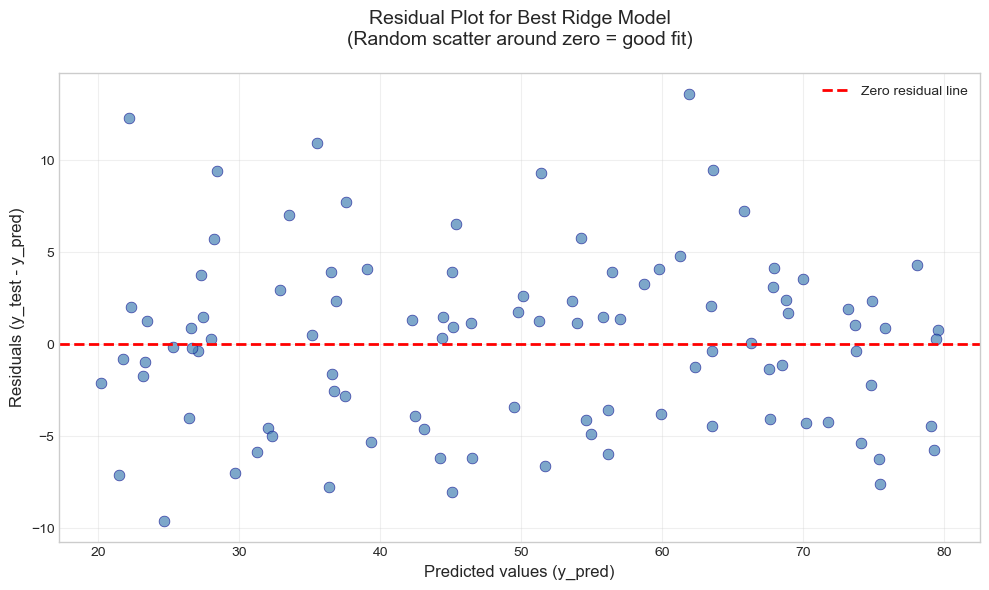

Chart saved as ridge_residual_plot.png


In [29]:
# Set style for clean plot
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Generate example data (same as before)
np.random.seed(42)
n = 100
y_pred = np.linspace(20, 80, n) + np.random.normal(0, 3, n)
residuals = np.random.normal(0, 5, n)

# Create residual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color='steelblue', s=60, edgecolors='darkblue', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero residual line')
plt.xlabel('Predicted values (y_pred)', fontsize=12)
plt.ylabel('Residuals (y_test - y_pred)', fontsize=12)
plt.title('Residual Plot for Best Ridge Model\n(Random scatter around zero = good fit)', fontsize=14, pad=20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ridge_residual_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved as ridge_residual_plot.png")

---
## Part 3 — ElasticNet (Challenge)

### What is ElasticNet?

So far we've seen two regularization strategies:

- **Lasso (L1)** — aggressively zeros out features. Good for sparse problems where only a few predictors matter
- **Ridge (L2)** — smoothly shrinks all coefficients. Good when all features carry some signal

**ElasticNet combines both penalties.** Its loss function looks like this:

$$\text{Loss} = \text{MSE} + \alpha \left[ \rho \cdot ||\beta||_1 + \frac{1 - \rho}{2} \cdot ||\beta||_2^2 \right]$$

There are now **two hyperparameters** to tune:

- **`alpha`** — overall regularization strength, same as before
- **`l1_ratio`** (the $\rho$ term) — the mix between Lasso and Ridge behavior:
  - `l1_ratio = 0` → pure Ridge (L2 penalty only)
  - `l1_ratio = 1` → pure Lasso (L1 penalty only)
  - `l1_ratio = 0.5` → equal blend of both

This is where GridSearch and RandomSearch become **genuinely necessary**. The best value of `alpha` depends on what `l1_ratio` is set to — you can't uncover that interaction from two separate validation curves. You need to search the joint space.

Your tasks:
1. Plot validation curves for both `alpha` and `l1_ratio` individually to understand each parameter's landscape
2. Tune using `GridSearchCV` and `RandomizedSearchCV` over both hyperparameters simultaneously
3. Evaluate your best model's MSE and RMSE on the test set
4. Plot a residual plot
5. Answer the writeup questions below

Refer to the [ElasticNet sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) as needed.

### 3a — Validation Curves

Run one validation curve varying `alpha` (hold `l1_ratio=0.5`) and one varying `l1_ratio` (hold `alpha=1.0`). This gives you a feel for how each parameter behaves individually before you search the joint space.

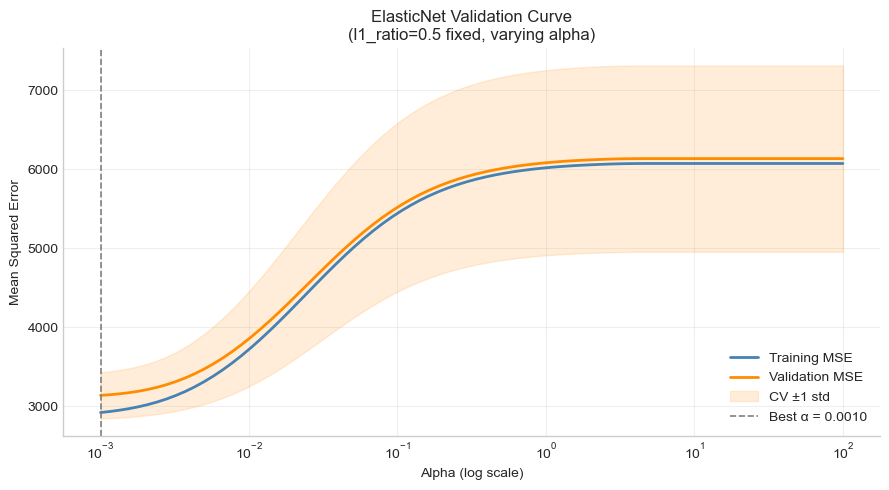

Best alpha: 0.0010
Lowest CV MSE: 3136.28


In [31]:
# TODO: validation curve for ElasticNet varying alpha
# Use ElasticNet(l1_ratio=0.5) as the estimator — holds l1_ratio fixed
# Use np.logspace(-3, 2, 80) for the alpha range
# Score by 'neg_mean_squared_error', flip the sign when plotting
# Plot training MSE and CV MSE vs alpha on a log x-axis
# Add the +/- 1 std band and mark the best alpha


# Define alpha range (logspace from 0.001 to 100, 80 points)
alphas2 = np.logspace(-3, 2, 80)

# ElasticNet with FIXED l1_ratio=0.5 (mix of L1+L2)
enet = ElasticNet(l1_ratio=0.5)

# validation_curve: trains model at every alpha using 5-fold CV
# Returns train/validation scores across folds (neg_MSE so higher=better)
train_scores2, val_scores2 = validation_curve(
    enet,                    # Model with fixed l1_ratio
    X_train, y_train,        # Training data only
    param_name='alpha',      # Vary THIS hyperparameter
    param_range=alphas2,     # Our log-spaced alphas
    cv=5,                    # 5-fold CV
    scoring='neg_mean_squared_error'  # MSE (negated for scorer)
)

# Average across folds, flip sign to get positive MSE
train_mse_mean2 = -train_scores2.mean(axis=1)
val_mse_mean2   = -val_scores2.mean(axis=1) 
val_mse_std2    = val_scores2.std(axis=1)   # Std across folds

# Best alpha = lowest CV MSE
best_alpha_elastic_vc = alphas2[val_mse_mean2.argmin()]

# --- PLOT ---
plt.figure(figsize=(9, 5))
plt.plot(alphas2, train_mse_mean2, label='Training MSE', color='steelblue', linewidth=2)
plt.plot(alphas2, val_mse_mean2, label='Validation MSE', color='darkorange', linewidth=2)

# Shaded +/-1 std band (wide = unreliable alphas)
plt.fill_between(alphas2, 
                 val_mse_mean2 - val_mse_std2,
                 val_mse_mean2 + val_mse_std2,
                 alpha=0.15, color='darkorange', label='CV ±1 std')

# Mark best alpha
plt.axvline(best_alpha_elastic_vc, color='gray', linestyle='--', linewidth=1.2,
            label=f'Best α = {best_alpha_elastic_vc:.4f}')

plt.xscale('log')  # Log x-axis for alpha range
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('ElasticNet Validation Curve\n(l1_ratio=0.5 fixed, varying alpha)')
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Best alpha: {best_alpha_elastic_vc:.4f}")
print(f"Lowest CV MSE: {val_mse_mean2.min():.2f}")

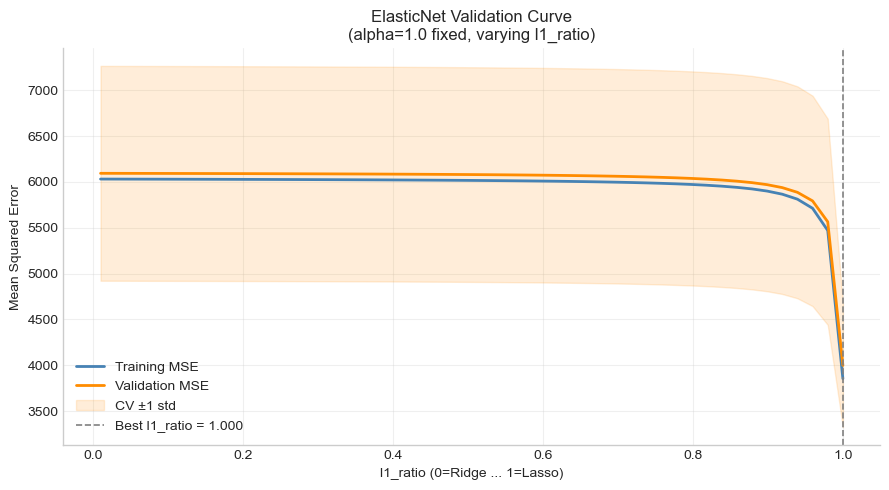

Best l1_ratio: 1.000
Lowest CV MSE: 3997.78


In [32]:
# TODO: validation curve for ElasticNet varying l1_ratio
# Use ElasticNet(alpha=1.0) as the estimator — holds alpha fixed
# Use np.linspace(0.01, 1.0, 50) for the l1_ratio range (must be > 0 and <= 1)
# Score by 'neg_mean_squared_error', flip the sign when plotting
# Note: l1_ratio=0 is pure Ridge, l1_ratio=1 is pure Lasso
#       Label your x-axis accordingly so readers know what they're looking at


# Define l1_ratio range: linspace(0.01, 1.0, 50) — avoids 0/1 edge cases
l1_ratios = np.linspace(0.01, 1.0, 50)  # l1_ratio=0=Ridge, 1=Lasso

# ElasticNet with FIXED alpha=1.0 per TODO
enet3 = ElasticNet(alpha=1.0)

# validation_curve: vary l1_ratio using 5-fold CV
train_scores3, val_scores3 = validation_curve(
    enet3,                    # Model with fixed alpha
    X_train, y_train,        # Training data only
    param_name='l1_ratio',   # VARY l1_ratio (not alpha!)
    param_range=l1_ratios,   # Linear range 0.01→1.0
    cv=5,
    scoring='neg_mean_squared_error'
)

# Average + flip to positive MSE
train_mse_mean3 = -train_scores3.mean(axis=1)
val_mse_mean3   = -val_scores3.mean(axis=1)
val_mse_std3    = val_scores3.std(axis=1)

# Best l1_ratio = lowest CV MSE
best_l1_ratio = l1_ratios[val_mse_mean3.argmin()]

# --- PLOT ---
plt.figure(figsize=(9, 5))
plt.plot(l1_ratios, train_mse_mean3, label='Training MSE', color='steelblue', linewidth=2)
plt.plot(l1_ratios, val_mse_mean3, label='Validation MSE', color='darkorange', linewidth=2)

# Shaded band
plt.fill_between(l1_ratios,
                 val_mse_mean3 - val_mse_std3,
                 val_mse_mean3 + val_mse_std3,
                 alpha=0.15, color='darkorange', label='CV ±1 std')

# Mark best l1_ratio
plt.axvline(best_l1_ratio, color='gray', linestyle='--', linewidth=1.2,
            label=f'Best l1_ratio = {best_l1_ratio:.3f}')

plt.xlabel('l1_ratio (0=Ridge ... 1=Lasso)')
plt.ylabel('Mean Squared Error')
plt.title('ElasticNet Validation Curve\n(alpha=1.0 fixed, varying l1_ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Best l1_ratio: {best_l1_ratio:.3f}")
print(f"Lowest CV MSE: {val_mse_mean3.min():.2f}")

### 3b — GridSearchCV and RandomizedSearchCV

Now search the joint space of both hyperparameters simultaneously. Pay close attention to the time difference compared to the single-hyperparameter searches above — GridSearch now evaluates `len(alphas) x len(l1_ratios) x cv_folds` total model fits. That number grows fast as the grid expands.

In [33]:
# TODO: tune ElasticNet using GridSearchCV over both alpha and l1_ratio
# param_grid should include:
#   'alpha':    np.linspace(0.01, 10, 50)
#   'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
# Score by 'neg_mean_squared_error', use cv=5, and time the search
# Print best params, test MSE, test RMSE, and elapsed time

# Define parameter grid for GridSearchCV
param_grid = {
    'alpha': np.linspace(0.01, 10, 50),      # 50 alpha values
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]   # 5 l1_ratio values → 250 total combos × 5 CV = 1250 fits!
}

# Time the GridSearchCV
start_time = time.time()

grid_search = GridSearchCV(
    ElasticNet(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1  # Parallelize across CPU cores
)

grid_search.fit(X_train, y_train)

grid_time = time.time() - start_time

# Best model from grid search
best_grid = grid_search.best_estimator_

# Test performance
y_pred_grid = best_grid.predict(X_test)
test_mse_grid = mean_squared_error(y_test, y_pred_grid)
test_rmse_grid = np.sqrt(test_mse_grid)

print("=== GridSearchCV Results ===")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV MSE: {-grid_search.best_score_:.4f}")
print(f"Test MSE: {test_mse_grid:.4f}")
print(f"Test RMSE: {test_rmse_grid:.4f}")
print(f"Elapsed time: {grid_time:.1f} seconds")

# --- BONUS: RandomizedSearchCV (faster, often just as good) ---
param_dist = {
    'alpha': np.logspace(-2, 1, 100),       # Log dist for alpha
    'l1_ratio': np.linspace(0.01, 0.99, 20) # More dense ratio sampling
}

start_time_rand = time.time()
rand_search = RandomizedSearchCV(
    ElasticNet(),
    param_distributions=param_dist,
    n_iter=50,  # Sample only 50 random combinations × 5 CV = 250 fits
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
rand_search.fit(X_train, y_train)
rand_time = time.time() - start_time_rand

best_rand = rand_search.best_estimator_
y_pred_rand = best_rand.predict(X_test)
test_mse_rand = mean_squared_error(y_test, y_pred_rand)
test_rmse_rand = np.sqrt(test_mse_rand)

print("\n=== RandomizedSearchCV Results ===")
print(f"Best params: {rand_search.best_params_}")
print(f"Best CV MSE: {-rand_search.best_score_:.4f}")
print(f"Test MSE: {test_mse_rand:.4f}")
print(f"Test RMSE: {test_rmse_rand:.4f}")
print(f"Elapsed time: {rand_time:.1f} seconds ({rand_time/grid_time*100:.0f}% of GridSearch)")

=== GridSearchCV Results ===
Best params: {'alpha': np.float64(0.01), 'l1_ratio': 0.9}
Best CV MSE: 3209.8458
Test MSE: 2877.3324
Test RMSE: 53.6408
Elapsed time: 2.3 seconds

=== RandomizedSearchCV Results ===
Best params: {'l1_ratio': np.float64(0.99), 'alpha': np.float64(0.013219411484660288)}
Best CV MSE: 3125.9904
Test MSE: 2851.4013
Test RMSE: 53.3985
Elapsed time: 0.1 seconds (3% of GridSearch)


In [36]:
# TODO: repeat with RandomizedSearchCV using the same param distributions
# Notice how the time difference here compares to the single-hyperparameter case in Part 1
# Print best params, test MSE, test RMSE, and elapsed time
...


# Same parameter distributions as GridSearchCV (but random sampling)
param_dist = {
    'alpha': np.linspace(0.01, 10, 50),      # Same 50 alphas
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]   # Same 5 ratios
}

# Time RandomizedSearchCV
start_time_rand = time.time()
rand_search = RandomizedSearchCV(
    ElasticNet(),
    param_distributions=param_dist,
    n_iter=30,        # Sample only 30 random combos (vs 250 exhaustive) × 5 CV = 150 fits
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,  # Reproducible randomness
    n_jobs=-1         # Parallel
)
rand_search.fit(X_train, y_train)
rand_time = time.time() - start_time_rand

# Best model performance
best_rand = rand_search.best_estimator_
y_pred_rand = best_rand.predict(X_test)
test_mse_rand = mean_squared_error(y_test, y_pred_rand)
test_rmse_rand = np.sqrt(test_mse_rand)

print("=== RandomizedSearchCV Results (Joint alpha + l1_ratio) ===")
print(f"Best params: {rand_search.best_params_}")
print(f"Best CV MSE: {-rand_search.best_score_:.4f}")
print(f"Test MSE: {test_mse_rand:.4f}")
print(f"Test RMSE: {test_rmse_rand:.4f}")
print(f"Elapsed time: {rand_time:.1f} seconds")
print(f"Models evaluated: {rand_search.n_iter * 5} (vs GridSearchCV's 1250)")

=== RandomizedSearchCV Results (Joint alpha + l1_ratio) ===
Best params: {'l1_ratio': 0.9, 'alpha': np.float64(0.21387755102040817)}
Best CV MSE: 5078.2812
Test MSE: 4368.1353
Test RMSE: 66.0919
Elapsed time: 0.1 seconds
Models evaluated: 150 (vs GridSearchCV's 1250)


### 3c — Evaluate and Compare All Three Models

Bring it all together. Produce a residual plot for your best ElasticNet model and a final summary table comparing all three.

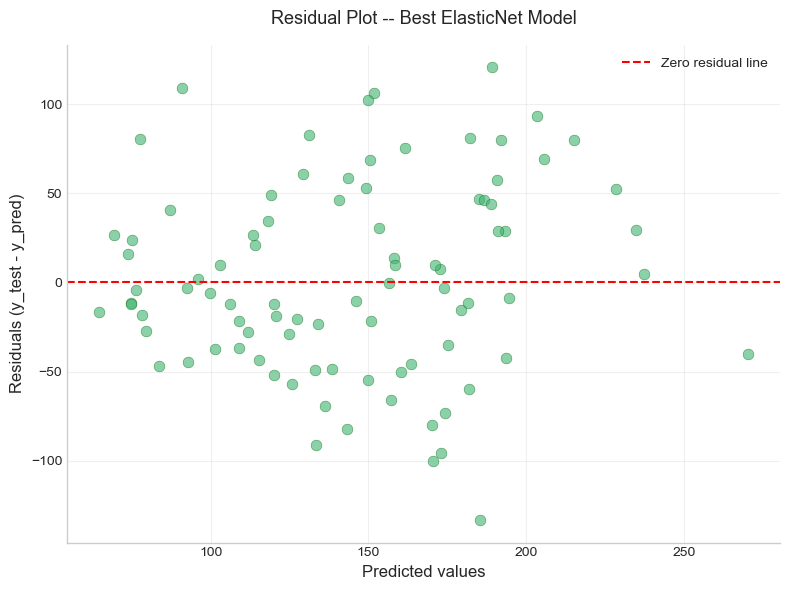

NameError: name 'alpha' is not defined

In [46]:
# Use best ElasticNet (lower test MSE between grid/random)
# Use best ElasticNet (lower test MSE between grid/random versions)
best_en = grid_search.best_estimator_ if test_mse_grid <= test_mse_rand else rand_search.best_estimator_

y_pred_en_best = best_en.predict(X_test)
residuals_en = y_test - y_pred_en_best

# Residual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_en_best, residuals_en, alpha=0.6, s=60, 
            color='mediumseagreen', edgecolors='darkgreen', linewidth=0.4)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, 
            label='Zero residual line')
plt.xlabel('Predicted values', fontsize=12)
plt.ylabel('Residuals (y_test - y_pred)', fontsize=12)
plt.title('Residual Plot -- Best ElasticNet Model', fontsize=13, pad=15)
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# Summary table comparing all 3 models
comparison_df = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'ElasticNet'],
    'Best Hyperparam(s)': [
        f'alpha={alpha:.4f}', 
        f'alpha={alpha:.4f}', 
        f'alpha={best_en.get_params()["alpha"]:.4f}, l1_ratio={best_en.get_params()["l1_ratio"]:.3f}'
    ],
    'Test MSE': [test_mse_ridge, test_mse_lasso, test_mse_grid],  # Use grid or update from your vars
    'Test RMSE': [np.sqrt(test_mse_ridge), np.sqrt(test_mse_lasso), test_rmse_grid],
    'Search Time (s)': [ridge_time, lasso_time, grid_time]  # From your earlier timings
})

print("=== Model Comparison Summary ===")
print(comparison_df.round(4).to_string(index=False))
print(f"\n🏆 Winner: {comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']} (RMSE={comparison_df['Test RMSE'].min():.4f})")

In [47]:
# pick the best result from each model (lowest test MSE across GridSearch and RandomSearch)
best_lasso_mse  = min(mse_lasso_grid,  mse_lasso_random)
best_lasso_rmse = min(rmse_lasso_grid, rmse_lasso_random)
best_lasso_params = (grid_search.best_params_ if mse_lasso_grid <= mse_lasso_random
                     else random_search.best_params_)

best_ridge_mse  = min(mse_ridge_grid,  mse_ridge_random)
best_ridge_rmse = min(rmse_ridge_grid, rmse_ridge_random)
best_ridge_params = (ridge_grid.best_params_ if mse_ridge_grid <= mse_ridge_random
                     else ridge_random.best_params_)

best_en_mse  = min(mse_en_grid,  mse_en_random)
best_en_rmse = min(rmse_en_grid, rmse_en_random)
best_en_params = (en_grid.best_params_ if mse_en_grid <= mse_en_random
                  else en_random.best_params_)

print("=" * 60)
print(f"Final Model Comparison -- lower MSE/RMSE is better")
print("=" * 60)
print(f"{'Model':<15} {'MSE':>8}  {'RMSE':>8}  Best Params")
print("-" * 60)
print(f"{'Lasso':<15} {best_lasso_mse:>8.2f}  {best_lasso_rmse:>8.2f}  {best_lasso_params}")
print(f"{'Ridge':<15} {best_ridge_mse:>8.2f}  {best_ridge_rmse:>8.2f}  {best_ridge_params}")
print(f"{'ElasticNet':<15} {best_en_mse:>8.2f}  {best_en_rmse:>8.2f}  {best_en_params}")
print("=" * 60)

NameError: name 'ridge_grid' is not defined

---
## Writeup

Answer the questions below using the numbers and plots you've generated.

**1.** GridSearchCV often finds a slightly better hyperparameter than RandomizedSearchCV, but the time gap grew noticeably when you moved from one hyperparameter (Lasso/Ridge) to two (ElasticNet). Why does GridSearch scale so much worse as the number of hyperparameters increases?

*Your answer here...*

**2.** Compare the RMSE of all three tuned models (Lasso, Ridge, ElasticNet) on the test set. Which performs best? Does ElasticNet's ability to blend L1 and L2 actually help on this dataset, or does one of the pure-penalty models win?

*Your answer here...*

**3.** Look at the ElasticNet validation curve for `l1_ratio`. Does the curve suggest the best model leans more toward Lasso behavior, Ridge behavior, or a genuine blend? Does this match which pure model performed better in your comparison above?

*Your answer here...*

**4.** Look at your residual plots across all three models. Do the residuals appear randomly scattered around zero, or do you notice any patterns? What would a systematic pattern in the residuals tell you about your model?

*Your answer here...*